In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import scanpy.external as sce
import harmonypy as hm
import numpy as np

In [10]:
adata = sc.read_h5ad('/mnt/home/gokulg/data/qiu22_early_integrated_scvi.h5ad')

In [36]:
adata.obs['day']

e6.5_E6.5_cell10_embryo2_single    E6.5
e6.5_E6.5_cell11_embryo2_single    E6.5
e6.5_E6.5_cell12_embryo2_single    E6.5
e6.5_E6.5_cell19_embryo2_single    E6.5
e6.5_E6.5_cell22_embryo2_single    E6.5
                                   ... 
E8.5-R3-T2-TGTGTTAGTTAGGTCT-1       NaN
E8.5-R3-T2-TGTGTTAGTTCAAGGA-1       NaN
E8.5-R3-T2-TGTGTTAGTTGTGGCC-1       NaN
E8.5-R3-T2-TGTGTTGAGCCTAAGC-1       NaN
E8.5-R3-T2-TGTGTTGAGGGCTACT-1       NaN
Name: day, Length: 194371, dtype: category
Categories (7, object): ['E6.5', 'E6.75', 'E7.5', 'E7.25', 'E7.75', 'E8.5a', 'E8.25']

In [ ]:
adata = sc.read_h5ad("/mnt/home/gokulg/data/embryos/qiu2022.h5ad")

# adata = adata[np.random.choice(adata.obs_names, 10000, replace=False)].copy()
cc = sc.read_h5ad("/mnt/home/gokulg/data/embryos/combined_counts.h5ad")

In [3]:
hvgs = pd.read_csv("/mnt/home/gokulg/data/embryos/hvg_v5.csv", header=None)[0].tolist()
conversion = pd.read_csv("/mnt/home/gokulg/data/mm39_annotations.csv", header=0)
gene_symbols = pd.read_csv("/mnt/home/gokulg/data/gene_symbols.tsv", sep='\t', header=0)

In [ ]:
conversion_dict = {}

# for i, row in conversion.iterrows():
#     conversion_dict[row['gene_ids']] = row['gene_name']
#     conversion_dict[row['gene_name']] = row['gene_ids']
#     conversion_dict[row['gene_ids'].split('.')[0]] = row['gene_name']

for i, row in gene_symbols.iterrows():
    conversion_dict[row['Gene stable ID']] = row['MGI symbol']
    conversion_dict[row['MGI symbol']] = row['Gene stable ID']
    conversion_dict[row['Gene stable ID'].split('.')[0]] = row['MGI symbol']
    
adata.var_names = adata.var['features'].tolist()
adata.var_names = [conversion_dict.get(v, v) for v in adata.var_names]
adata.var_names_make_unique()

# adata.var_names = gene_symbols['Gene stable ID'].tolist()

In [ ]:
adata.var_names = [conversion_dict.get(v, v) for v in adata.var_names]
adata.var_names_make_unique()
adata_hvg = adata[:, [h for h in hvgs if h in adata.var_names]].copy()
cc_hvg = cc[:, [h for h in adata_hvg.var_names]].copy()
cc_hvg.obs['time'] = [float(x.split('-')[0][1:]) for x in cc_hvg.obs['embryo'].values]
# cc_hvg = cc_hvg[cc_hvg.obs['time'] < 8.6, :].copy()
cc_hvg = cc_hvg[cc_hvg.obs['time'] - 8.5 < 0.1, :].copy()

# cc_hvg = cc_hvg[cc_hvg.obs['time'] < 8.1, :].copy()

# check that data are integer counts
assert [(adata_hvg.X.data[:10].astype(int) == adata_hvg.X.data[:10]).all()]
assert [(cc_hvg.X.data[:10].astype(int) == cc_hvg.X.data[:10]).all()]

# overlapping_days = ['E6.5', 'E6.75', 'E7.0', 'E7.25', 'E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5a',]
# overlapping_days = ['E6.5', 'E6.75', 'E7.0', 'E7.25', 'E7.5', 'E7.75', 'E8.0', 'E8.25']
overlapping_days = ['E8.5b']
adata_hvg_overlap = adata_hvg[adata_hvg.obs['day'].isin(overlapping_days)].copy()
combined = ad.concat([adata_hvg_overlap, cc_hvg], axis='obs', join='outer', label='dataset', keys=['qiu2022', 'devmap'])

/tmp/ipykernel_10936/395172792.py:17: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  combined = ad.concat([adata_hvg_overlap, cc_hvg], axis='obs', join='outer', label='dataset', keys=['qiu2022', 'devmap'])


In [6]:
combined.obs['dataset'].value_counts()

dataset
devmap     116790
qiu2022     10000
Name: count, dtype: int64

In [7]:
# preprocess and pca combined
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
# sc.pp.scale(combined, max_value=10)
# sc.tl.pca(combined, svd_solver='arpack')

In [8]:
sc.tl.rank_genes_groups(combined, groupby='dataset', method='wilcoxon')

In [9]:
top_genes_df = sc.get.rank_genes_groups_df(combined, group=None, key='rank_genes_groups')

k = 1000
top_k = top_genes_df.groupby('group').head(k)

/tmp/ipykernel_10936/2909998046.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_k = top_genes_df.groupby('group').head(k)


In [10]:
gene_subset = [x for x in combined.var_names if x not in top_k['names'].values]
combined = combined[:, gene_subset].copy()

In [11]:
# pca
sc.tl.pca(combined)

In [12]:
# sce.pp.harmony_integrate(combined, "dataset")

pcs = combined.obsm['X_pca'] # (n_cells, n_pcs)
harmony_out = hm.run_harmony(pcs, combined.obs, "dataset")
combined.obsm['X_pca_harmony'] = harmony_out.Z_corr

2026-03-20 11:44:03,319 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-03-20 11:44:03,319 - harmonypy - INFO -   Parameters:
2026-03-20 11:44:03,320 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-20 11:44:03,320 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-20 11:44:03,321 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-20 11:44:03,321 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-20 11:44:03,321 - harmonypy - INFO -     nclust: 100
2026-03-20 11:44:03,322 - harmonypy - INFO -     block_size: 0.05
2026-03-20 11:44:03,322 - harmonypy - INFO -     lamb: [1. 1.]
2026-03-20 11:44:03,323 - harmonypy - INFO -     theta: [2. 2.]
2026-03-20 11:44:03,323 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-20 11:44:03,323 - harmonypy - INFO -     verbose: True
2026-03-20 11:44:03,323 - harmonypy - INFO -     random_state: 0
2026-03-20 11:44:03,326 - harmonypy - INFO -   Data: 50 PCs × 126790 cells
2026-03-20 11:44:03,326 - harmonypy - INF

In [13]:
# write out combined
combined.write_h5ad("/mnt/home/gokulg/data/embryos/harmony_integrated_qiu2022.h5ad")

In [14]:
# umap
sc.pp.neighbors(combined, use_rep='X_pca_harmony')
sc.tl.umap(combined)

In [15]:
# write out combined, now with umap
combined.write_h5ad("/mnt/home/gokulg/data/embryos/harmony_integrated_qiu2022_umap.h5ad")

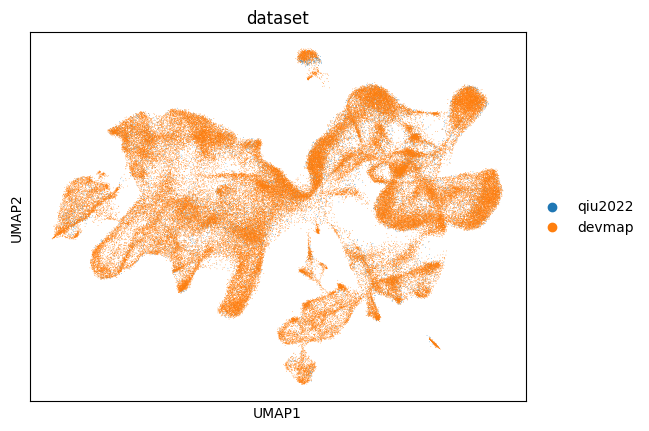

In [16]:
sc.pl.umap(combined, color=['dataset'], wspace=0.4)

<Axes: >

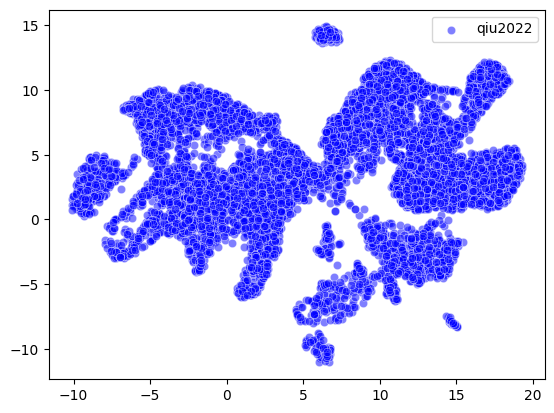

In [20]:
sns.scatterplot(x=combined[combined.obs['dataset'] == 'qiu2022'].obsm['X_umap'][:, 0], 
                y=combined[combined.obs['dataset'] == 'qiu2022'].obsm['X_umap'][:, 1], 
                color='blue', label='qiu2022', alpha=0.5)

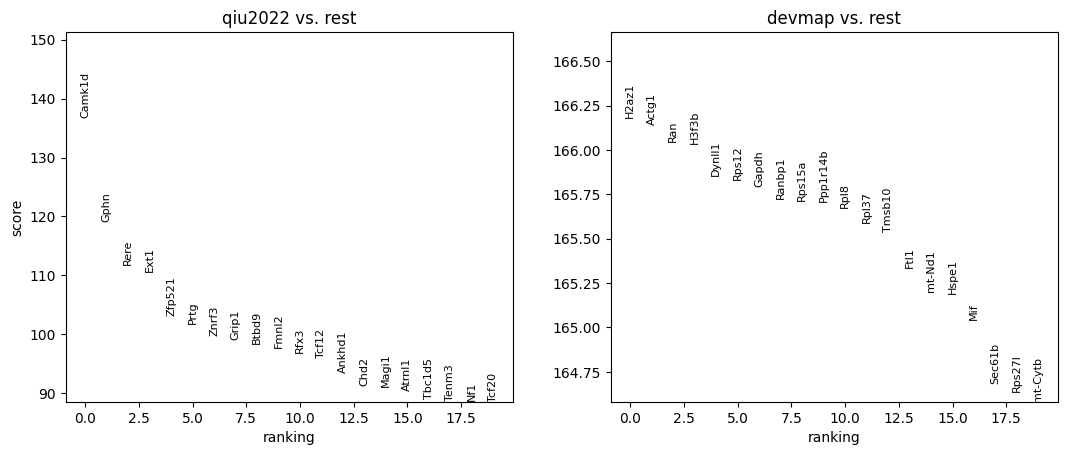

In [17]:
sc.pl.rank_genes_groups(combined, n_genes=20, sharey=False)